In [175]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [176]:
df=pd.DataFrame()

In [177]:
df['X1']=[1,2,3,4,5,6,6,7,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['lable']=[1,1,0,1,0,1,0,1,0,0]


In [178]:
df

,X1,X2,lable
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

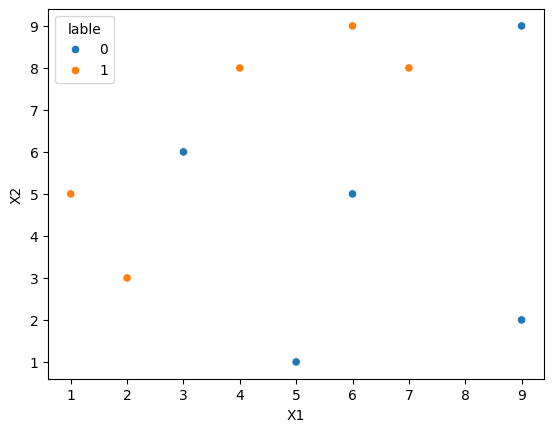

In [179]:
import seaborn as sns
sns.scatterplot(x=df["X1"],y=df["X2"],hue=df["lable"])

In [180]:
df['weights']=1/df.shape[0]

In [181]:
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(max_depth=1)

In [182]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

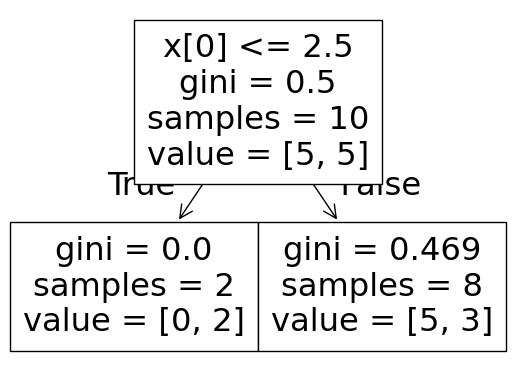

In [183]:
dt1.fit(X,y)
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

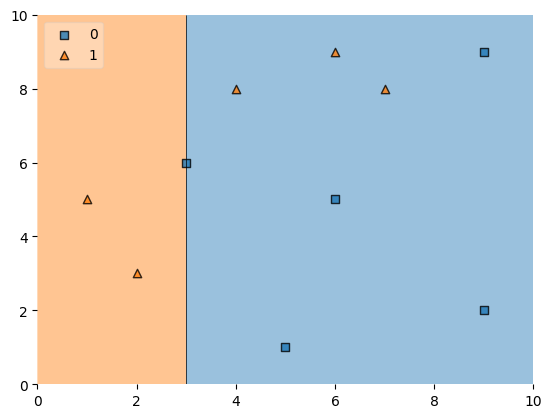

In [184]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [185]:
df['y_pred']=dt1.predict(X)

In [186]:
df

,X1,X2,lable,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [187]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error + 0.0000000001)
 

In [188]:
#Step 3 - calculate model weight
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.4236489302150304)

In [189]:
# step 4 Upadate weights
def update_row_weights(row,alpha=0.423):
    if row['lable']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
        

In [190]:
df["updated_weights"]=df.apply(update_row_weights,axis=1)

In [191]:
df

,X1,X2,lable,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [192]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [193]:
df["normalized_weights"]=df["updated_weights"]/df['updated_weights'].sum()

In [194]:
df

,X1,X2,lable,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [195]:
df["normalized_weights"].sum()

np.float64(1.0)

In [196]:
df['cumsum_upper']=np.cumsum(df["normalized_weights"])

In [197]:
df['cumsum_lower']=df['cumsum_upper']-df["normalized_weights"]

In [198]:
df[['X1','X2','lable','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,lable,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [199]:
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row["cumsum_upper"]>a and row["cumsum_lower"]<a:
                indices.append(index)
    return indices

In [200]:
index_values=create_new_dataset(df)
index_values

[2, 4, 8, 7, 6, 3, 0, 7, 5, 4]

In [201]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [202]:
second_df

,X1,X2,lable,weights
2,3,6,0,0.1
4,5,1,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
6,6,5,0,0.1
3,4,8,1,0.1
0,1,5,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1


[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

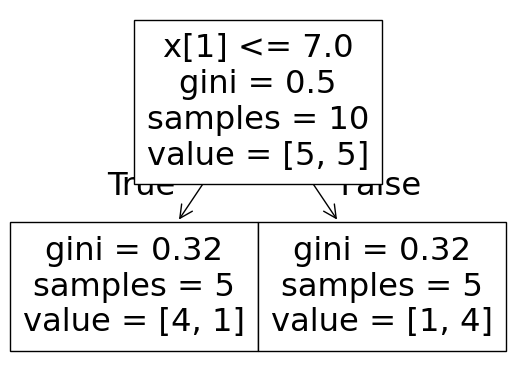

In [203]:
dt2=DecisionTreeClassifier(max_depth=1)
X=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values
dt2.fit(X,y)
plot_tree(dt2)

<Axes: >

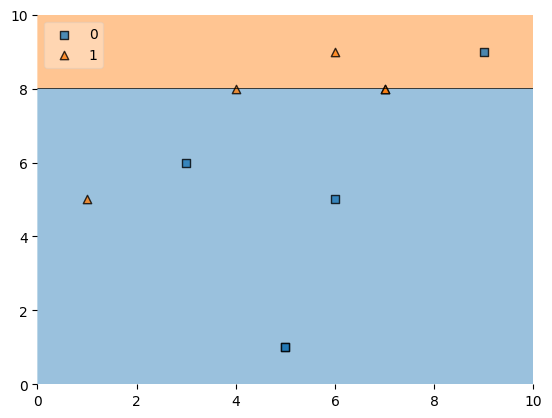

In [204]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [205]:
second_df['y_pred']=dt2.predict(X)
alpha2=calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886736653)

In [206]:
def update_row_weights(row,alpha=1.09):
    if row['lable']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
second_df["updated_weights"]=second_df.apply(update_row_weights,axis=1)
second_df["normalized_weights"]=second_df["updated_weights"]/second_df['updated_weights'].sum()
second_df['cumsum_upper']=np.cumsum(second_df["normalized_weights"])
second_df['cumsum_lower']=second_df['cumsum_upper']-second_df["normalized_weights"]
second_df[['X1','X2','lable','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,lable,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.033622,0.000000,0.038922
4,5,1,0,0.1,0,0.033622,0.038922,0.077843
8,9,9,0,0.1,1,0.297427,0.077843,0.422157
7,7,8,1,0.1,1,0.033622,0.422157,0.461078
6,6,5,0,0.1,0,0.033622,0.461078,0.500000
3,4,8,1,0.1,1,0.033622,0.500000,0.538922
0,1,5,1,0.1,0,0.297427,0.538922,0.883235
7,7,8,1,0.1,1,0.033622,0.883235,0.922157
5,6,9,1,0.1,1,0.033622,0.922157,0.961078
4,5,1,0,0.1,0,0.033622,0.961078,1.000000


In [207]:
index_values=create_new_dataset(second_df)
index_values

[0, 0, 0, 0, 0, 0, 8, 8, 3, 8]

In [208]:
third_df=second_df.iloc[index_values,[0,1,2,3]]

[Text(0.5, 0.75, 'x[0] <= 4.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

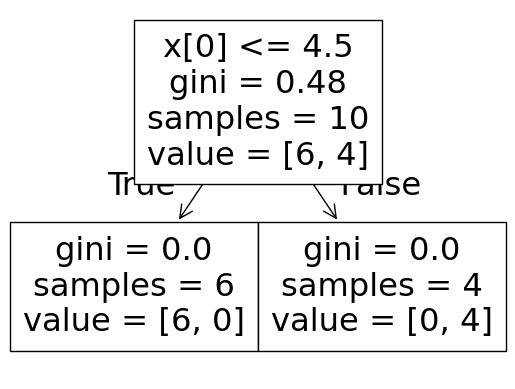

In [209]:
dt3=DecisionTreeClassifier(max_depth=1)
X=third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values
dt3.fit(X,y)
plot_tree(dt3)

<Axes: >

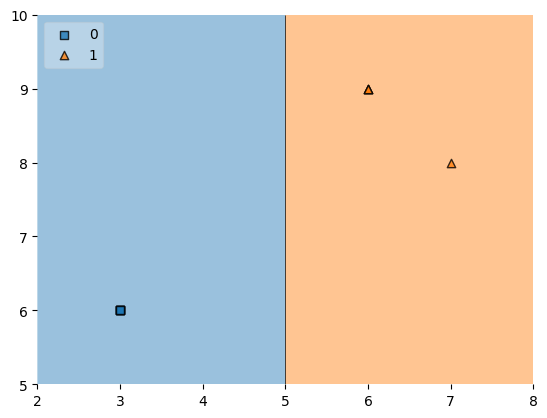

In [210]:
plot_decision_regions(X,y,clf=dt3,legend=2)


In [211]:
third_df['y_pred']=dt3.predict(X)
alpha3=calculate_model_weight(0.1)
alpha3

np.float64(1.0986122886736653)

In [212]:
def update_row_weights(row,alpha=1.09):
    if row['lable']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
third_df["updated_weights"]=third_df.apply(update_row_weights,axis=1)
third_df["normalized_weights"]=third_df["updated_weights"]/third_df['updated_weights'].sum()
third_df['cumsum_upper']=np.cumsum(third_df["normalized_weights"])
third_df['cumsum_lower']=third_df['cumsum_upper']-third_df["normalized_weights"]
third_df[['X1','X2','lable','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,lable,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.033622,0.0,0.1
2,3,6,0,0.1,0,0.033622,0.1,0.2
2,3,6,0,0.1,0,0.033622,0.2,0.3
2,3,6,0,0.1,0,0.033622,0.3,0.4
2,3,6,0,0.1,0,0.033622,0.4,0.5
2,3,6,0,0.1,0,0.033622,0.5,0.6
5,6,9,1,0.1,1,0.033622,0.6,0.7
5,6,9,1,0.1,1,0.033622,0.7,0.8
7,7,8,1,0.1,1,0.033622,0.8,0.9
5,6,9,1,0.1,1,0.033622,0.9,1.0


In [213]:
print(alpha1,alpha2,alpha3)

0.4236489302150304 1.0986122886736653 1.0986122886736653


In [214]:
#prediction

In [215]:
query=np.array([1,5]).reshape(1,2)
print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))

[1]
[0]
[0]


In [216]:
ans=alpha1*1 + alpha2*1 +alpha3*(-1)
ans

np.float64(0.42364893021503036)

In [217]:
np.sign(ans)

np.float64(1.0)

In [218]:
query=np.array([9,9]).reshape(1,2)
print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))

[0]
[1]
[1]


In [219]:
ans=alpha1*(-1) + alpha2*(1) +alpha3*(1)
ans

np.float64(1.7735756471323003)

In [220]:
np.sign(ans)

np.float64(1.0)